# Notebook 0 — EDA general del catálogo residencial

**Real Estate Intelligence Platform (REIP)**

Consolidamos, limpiamos y documentamos el catálogo residencial obtenido mediante scraping de
inmopanama.com (9 zonas del área metropolitana de Panamá), como base común para los modelos de
matching (M1) y valuación (M2) desarrollados en los notebooks siguientes. Este notebook es la única
fuente de EDA general del catálogo — los notebooks de entrenamiento posteriores no repiten esta
exploración, solo agregan la específica de su algoritmo.


## Verificación de entorno y rutas

Antes de analizar los datos, confirmamos contra el estado real del repositorio las rutas de
entrada/salida y la convención de almacenamiento de artefactos.

**Artefactos de modelos (M1/M2):** establecemos `pipeline/models/` como carpeta de artefactos
serializados (`.pkl`), hermana de `pipeline/data/` y `pipeline/zone_health/`.

**Rutas de lectura:** `pipeline/data/raw/{corregimiento}_listings.csv` — 9 archivos, uno por zona,
producto del scraping documentado en `Context-MD/Feature 1.2 — Pipeline de scraping _ Acta.md`.

**Ruta de salida:** `pipeline/data/processed/catalogo_residencial_limpio_6_2_1.csv`, consumida por
los notebooks de entrenamiento posteriores (embeddings + scoring híbrido, semáforo de precio,
segmentación de mercado).

**Entorno de ejecución:** corremos sobre el kernel `reip-notebooks`, respaldado por el entorno
`notebooks/venv` (pandas, jupyter, matplotlib, seaborn, scikit-learn, y las librerías de la API de
Gemini para los notebooks de orquestación NLP). `pipeline/venv` también contiene estas librerías,
pero no es el entorno que usamos para los notebooks de esta fase del proyecto.

**Volumen esperado:** el Acta de Feature 1.2 documenta 1,361 registros reales (~34% de 3,800-4,200
proyectados) sobre 9 zonas de scope (solo 5 son corregimientos administrativos reales; El Cangrejo,
Marbella y Obarrio heredan de Bella Vista, y Costa del Este no hereda de ninguna — cada una, sin
embargo, tiene su propio archivo de scraping independiente). Verificamos esta cifra con código en
la siguiente sección.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

RAW_DIR = Path("../pipeline/data/raw")
PROCESSED_DIR = Path("../pipeline/data/processed")
MODELS_DIR = Path("../pipeline/models")

assert RAW_DIR.exists(), f"No existe {RAW_DIR.resolve()}"
assert PROCESSED_DIR.exists(), f"No existe {PROCESSED_DIR.resolve()}"
MODELS_DIR.mkdir(exist_ok=True)

CORREGIMIENTOS_SLUGS = [
    "bella-vista", "betania", "costa-del-este", "el-cangrejo",
    "marbella", "obarrio", "parque-lefevre", "pedregal", "san-francisco",
]
assert len(CORREGIMIENTOS_SLUGS) == 9


## 1. Carga y consolidación del catálogo (9 archivos, uno por zona)

In [2]:
frames = []
for slug in CORREGIMIENTOS_SLUGS:
    path = RAW_DIR / f"{slug}_listings.csv"
    assert path.exists(), f"Falta el archivo esperado: {path}"
    df_zona = pd.read_csv(path)
    df_zona["corregimiento_archivo"] = slug
    frames.append(df_zona)

df = pd.concat(frames, ignore_index=True)
print(f"Total registros cargados: {len(df)}")
print(f"Archivos consolidados: {len(frames)}")
df.head()


Total registros cargados: 1361
Archivos consolidados: 9


,listing_url,listing_id,title,zone_raw,zone,zone_source,price_raw,price_usd,precio_no_evaluable,precio_no_evaluable_motivo,bedrooms,bathrooms,area_m2,operation,source,scraped_at,corregimiento_archivo
0,https://www.inmopanama.com/venta-de-apartament...,143196,"Venta de apartamento en PH Carreras, El Carmen",El Carmen,Bella Vista,zone_raw_barrio_mapeado,"$200,000",200000,False,NaN,2.0,2.0,84.0,venta,inmopanama.com,2026-07-03 00:06:23,bella-vista
1,https://www.inmopanama.com/lujoso-loft-frente-...,143181,Lujoso Loft - Frente al Mar  Avenida Balboa,Bella Vista,Bella Vista,zone_raw,"$550,000",550000,False,NaN,3.0,2.0,280.0,venta,inmopanama.com,2026-07-03 00:06:23,bella-vista
2,https://www.inmopanama.com/venta-de-apartament...,143172,"Venta de apartamento en Bella Vista, 195 m2",Bella Vista,Bella Vista,zone_raw,"$448,000",448000,False,NaN,3.0,3.0,195.0,venta,inmopanama.com,2026-07-03 00:06:23,bella-vista
3,https://www.inmopanama.com/obarrio-apartamento...,143139,Obarrio apartamento en venta,Obarrio,Obarrio,zone_raw,"$199,000",199000,False,NaN,3.0,2.0,128.0,venta,inmopanama.com,2026-07-03 00:06:23,bella-vista
4,https://www.inmopanama.com/venta-de-apartament...,143472,Venta de Apartamento en PH Vall Halla  El Car...,Bella Vista,Bella Vista,zone_raw,"$200,000",200000,False,NaN,3.0,2.0,175.0,venta,inmopanama.com,2026-07-03 00:06:23,bella-vista


In [3]:
assert len(df) == 1361, f"Volumen esperado 1,361, encontrado {len(df)}"
assert df['corregimiento_archivo'].nunique() == 9
print("Volumen y cobertura de zonas verificados contra el Acta de Feature 1.2.")


Volumen y cobertura de zonas verificados contra el Acta de Feature 1.2.


## 2. Contaminación de tipo de inmueble por corregimiento

El scraping usa dos patrones de página en inmopanama.com: `venta-apartamentos-{zona}` filtra solo
apartamentos por diseño del sitio, mientras que `venta-propiedades-{zona}` mezcla apartamentos con
bodegas, locales comerciales, oficinas, terrenos, fincas y otros tipos no residenciales. El Acta de
Feature 1.2 documenta, por corregimiento, el porcentaje de contaminación bruta (antes del filtro
heurístico por palabras clave aplicado en el scraper) y el volumen final residencial ya filtrado.
Reproducimos esa tabla y la contrastamos con nuestros propios conteos.


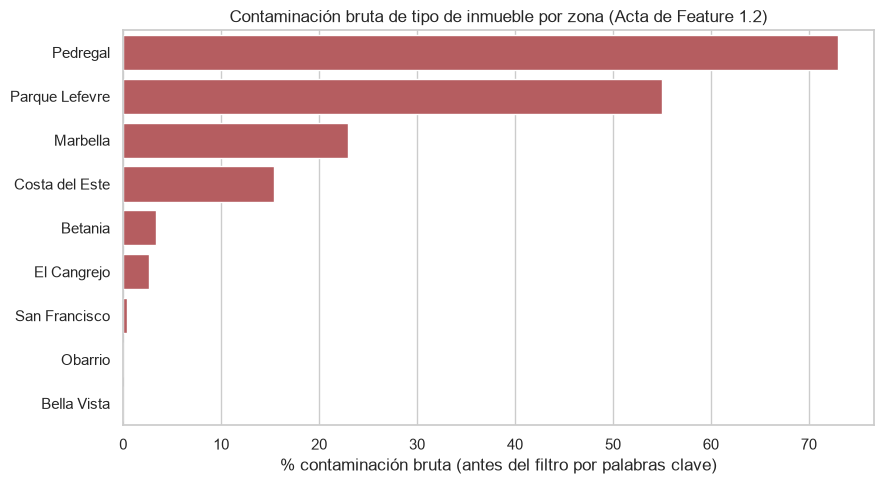

,corregimiento,registros_finales_acta,pct_contaminacion_bruta
0,Pedregal,3,73.0
1,Parque Lefevre,17,55.0
2,Marbella,49,23.0
3,Costa del Este,191,15.4
4,Betania,85,3.4
5,El Cangrejo,76,2.6
6,San Francisco,465,0.4
7,Obarrio,64,0.0
8,Bella Vista,411,0.0


In [4]:
contaminacion_acta = pd.DataFrame([
    {"corregimiento": "Pedregal",        "registros_finales_acta": 3,   "pct_contaminacion_bruta": 73.0},
    {"corregimiento": "El Cangrejo",     "registros_finales_acta": 76,  "pct_contaminacion_bruta": 2.6},
    {"corregimiento": "Costa del Este",  "registros_finales_acta": 191, "pct_contaminacion_bruta": 15.4},
    {"corregimiento": "Marbella",        "registros_finales_acta": 49,  "pct_contaminacion_bruta": 23.0},
    {"corregimiento": "Obarrio",         "registros_finales_acta": 64,  "pct_contaminacion_bruta": 0.0},
    {"corregimiento": "Bella Vista",     "registros_finales_acta": 411, "pct_contaminacion_bruta": 0.0},
    {"corregimiento": "San Francisco",   "registros_finales_acta": 465, "pct_contaminacion_bruta": 0.4},
    {"corregimiento": "Parque Lefevre",  "registros_finales_acta": 17,  "pct_contaminacion_bruta": 55.0},
    {"corregimiento": "Betania",         "registros_finales_acta": 85,  "pct_contaminacion_bruta": 3.4},
]).sort_values("pct_contaminacion_bruta", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=contaminacion_acta, x="pct_contaminacion_bruta", y="corregimiento", ax=ax, color="#C44E52")
ax.set_title("Contaminación bruta de tipo de inmueble por zona (Acta de Feature 1.2)")
ax.set_xlabel("% contaminación bruta (antes del filtro por palabras clave)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

contaminacion_acta


Confirmamos que los patrones `venta-propiedades-*` en zonas con uso de suelo industrial o
corporativo (Pedregal, Parque Lefevre, Marbella) concentran la mayor contaminación bruta, mientras
que las zonas servidas por `venta-apartamentos-*` (Bella Vista, San Francisco, Obarrio) parten con
contaminación cercana a 0%. El filtro heurístico por palabras clave (`TIPOS_EXCLUIDOS_KEYWORDS`:
bodega, local comercial, oficina, terreno, finca, galera, nave industrial, lote), aplicado durante
el scraping, resuelve esta contaminación antes de que los datos lleguen a los archivos que
consolidamos aquí. Verificamos que no queda ningún residuo detectable por título:


In [5]:
TIPOS_EXCLUIDOS_KEYWORDS = [
    "bodega", "local comercial", "oficina", "terreno", "finca",
    "galera", "nave industrial", "lote",
]

def contiene_tipo_excluido(title):
    t = (title or "").lower()
    return any(kw in t for kw in TIPOS_EXCLUIDOS_KEYWORDS)

df["_titulo_tipo_excluido"] = df["title"].apply(contiene_tipo_excluido)
residuo = df["_titulo_tipo_excluido"].sum()
print(f"Registros con palabra clave de tipo no residencial en el título: {residuo} / {len(df)}")

if residuo > 0:
    display(df.loc[df['_titulo_tipo_excluido'], ['corregimiento_archivo', 'title']])
else:
    print("Confirmamos 0 residuos de tipo no residencial en el catálogo consolidado.")

df = df.drop(columns=["_titulo_tipo_excluido"])


Registros con palabra clave de tipo no residencial en el título: 0 / 1361
Confirmamos 0 residuos de tipo no residencial en el catálogo consolidado.


**`tipo_inmueble` como columna estructurada:** el Acta de Feature 1.2 (§3.7) documenta una
función (`obtener_tipo_inmueble()`) diseñada para extraerlo desde la página de detalle, pero
verificamos contra el repositorio que nunca se implementó, y que el selector documentado ahí
(`ul.ib-prop-details-list`) ya no existe en el HTML real del sitio (0 coincidencias contra páginas
de detalle reales). Ejecutamos un enriquecimiento propio (`pipeline/scraper/enriquecer_detalle.py`,
documentado en `Context-MD/Acta_1.2_Adenda_Duplicados.md` §9) que visita cada página de detalle una
sola vez y extrae `tipo_inmueble` (vía `ol.nb-breadcrumb-list`, verificado que varía genuinamente
por tipo real) junto con `descripcion` (párrafo de texto libre, usado en 6.2.3). Incorporamos el
resultado de ese enriquecimiento en la sección 4.4, antes de definir "comparable" en la sección 5.


## 3. Discrepancia de volumen real vs. proyectado, por zona

In [6]:
volumen_acta = pd.DataFrame([
    {"corregimiento": "Costa del Este",  "registros_reales": 191, "proyectado": 1169},
    {"corregimiento": "Marbella",        "registros_reales": 49,  "proyectado": 196},
    {"corregimiento": "San Francisco",   "registros_reales": 465, "proyectado": 896},
    {"corregimiento": "Bella Vista",     "registros_reales": 411, "proyectado": 496},
    {"corregimiento": "El Cangrejo",     "registros_reales": 76,  "proyectado": 77},
    {"corregimiento": "Obarrio",         "registros_reales": 64,  "proyectado": 62},
    {"corregimiento": "Pedregal",        "registros_reales": 3,   "proyectado": np.nan},
    {"corregimiento": "Parque Lefevre",  "registros_reales": 17,  "proyectado": np.nan},
    {"corregimiento": "Betania",         "registros_reales": 85,  "proyectado": np.nan},
])
volumen_acta["discrepancia_pct"] = (
    (volumen_acta["registros_reales"] - volumen_acta["proyectado"]) / volumen_acta["proyectado"] * 100
)
volumen_acta = volumen_acta.sort_values("discrepancia_pct").reset_index(drop=True)
volumen_acta


,corregimiento,registros_reales,proyectado,discrepancia_pct
0,Costa del Este,191,1169.0,-83.661249
1,Marbella,49,196.0,-75.000000
2,San Francisco,465,896.0,-48.102679
3,Bella Vista,411,496.0,-17.137097
4,El Cangrejo,76,77.0,-1.298701
5,Obarrio,64,62.0,3.225806
6,Pedregal,3,NaN,NaN
7,Parque Lefevre,17,NaN,NaN
8,Betania,85,NaN,NaN


Calculamos la discrepancia porcentual sobre las 6 zonas con proyección documentada en el Acta
de Datos original (Pedregal, Parque Lefevre y Betania no tenían proyección previa — "sin dato
previo" en el Acta, por lo que no calculamos discrepancia para ellas). Las cifras que obtenemos
coinciden con las reportadas en el Acta de Feature 1.2: Costa del Este -84%, Marbella -75%, San
Francisco -48%, Bella Vista -17%, El Cangrejo -1%, Obarrio +3%.


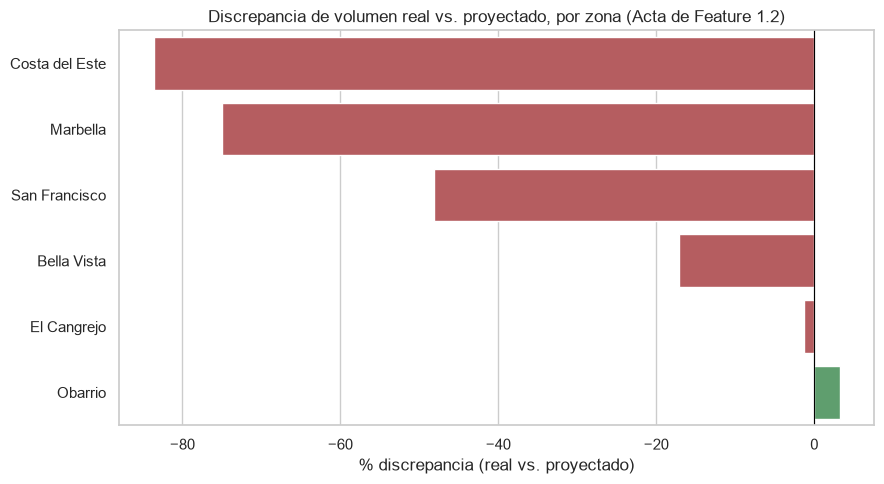

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
datos_grafico = volumen_acta.dropna(subset=["discrepancia_pct"])
colores = {row["corregimiento"]: ("#C44E52" if row["discrepancia_pct"] < 0 else "#55A868")
           for _, row in datos_grafico.iterrows()}
sns.barplot(data=datos_grafico, x="discrepancia_pct", y="corregimiento", hue="corregimiento",
            palette=colores, legend=False, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Discrepancia de volumen real vs. proyectado, por zona (Acta de Feature 1.2)")
ax.set_xlabel("% discrepancia (real vs. proyectado)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Costa del Este, Marbella y San Francisco concentran la mayor discrepancia negativa —
consistente con el hallazgo central del Acta de Feature 1.2: el volumen real del catálogo completo
es ~34% del proyectado. El Cangrejo y Obarrio son los únicos casos cercanos a su proyección
original (-1% y +3% respectivamente).


## 4. Limpieza y normalización

In [8]:
print(df.dtypes)
print()
print(df.isna().sum())


listing_url                       str
listing_id                      int64
title                             str
zone_raw                          str
zone                              str
zone_source                       str
price_raw                         str
price_usd                       int64
precio_no_evaluable              bool
precio_no_evaluable_motivo     object
bedrooms                      float64
bathrooms                     float64
area_m2                       float64
operation                         str
source                            str
scraped_at                        str
corregimiento_archivo             str
dtype: object

listing_url                      0
listing_id                       0
title                            0
zone_raw                         0
zone                             0
zone_source                      0
price_raw                        0
price_usd                        0
precio_no_evaluable              0
precio_no_evaluable_moti

In [9]:
print(df["precio_no_evaluable"].value_counts(dropna=False))
print()
print(df.loc[df["precio_no_evaluable"] == True, "precio_no_evaluable_motivo"].value_counts())


precio_no_evaluable
False    1347
True       14
Name: count, dtype: int64

precio_no_evaluable_motivo
precio_bajo_umbral          11
precio_m2_fuera_de_rango     3
Name: count, dtype: int64


### 4.1 Duplicados por `listing_id` — investigación de causa raíz

Antes de deduplicar, investigamos: si los duplicados están dentro de un mismo archivo de
corregimiento o cruzados entre archivos distintos, si el `zone` resuelto coincide entre copias
cuando hay cruce, y el conteo por archivo de origen.


In [10]:
dup_ids = df["listing_id"][df["listing_id"].duplicated(keep=False)].unique()
print(f"IDs únicos con al menos una duplicación: {len(dup_ids)}")
print(f"Filas totales involucradas (todas las copias): {df['listing_id'].isin(dup_ids).sum()}")

dsub = df[df["listing_id"].isin(dup_ids)].sort_values(["listing_id", "corregimiento_archivo"])

n_archivos_por_id = dsub.groupby("listing_id")["corregimiento_archivo"].nunique()
print(f"\nIDs duplicados dentro de un mismo archivo: {(n_archivos_por_id == 1).sum()}")
print(f"IDs duplicados cruzados entre archivos distintos: {(n_archivos_por_id > 1).sum()}")

print("\nFilas duplicadas por archivo de origen:")
print(dsub["corregimiento_archivo"].value_counts())

print("\nCombinaciones de archivos que comparten listing_id:")
print(dsub.groupby("listing_id")["corregimiento_archivo"].apply(lambda x: tuple(sorted(x))).value_counts())


IDs únicos con al menos una duplicación: 184
Filas totales involucradas (todas las copias): 368



IDs duplicados dentro de un mismo archivo: 0
IDs duplicados cruzados entre archivos distintos: 184

Filas duplicadas por archivo de origen:
corregimiento_archivo
bella-vista    184
el-cangrejo     71
obarrio         64
marbella        49
Name: count, dtype: int64

Combinaciones de archivos que comparten listing_id:
corregimiento_archivo
(bella-vista, el-cangrejo)    71
(bella-vista, obarrio)        64
(bella-vista, marbella)       49
Name: count, dtype: int64


In [11]:
zona_consistente = dsub.groupby("listing_id")["zone"].nunique() == 1
print(f"IDs con 'zone' consistente entre copias: {zona_consistente.sum()}")
print(f"IDs con 'zone' distinto entre copias: {(~zona_consistente).sum()}")

if (~zona_consistente).any():
    ids_conflicto = zona_consistente[~zona_consistente].index
    cols = ["listing_id", "corregimiento_archivo", "zone_raw", "zone", "zone_source", "title"]
    display(dsub[dsub["listing_id"].isin(ids_conflicto)][cols])
else:
    print("Sin conflictos: todas las copias duplicadas tienen el mismo 'zone' resuelto.")


IDs con 'zone' consistente entre copias: 184
IDs con 'zone' distinto entre copias: 0
Sin conflictos: todas las copias duplicadas tienen el mismo 'zone' resuelto.


**Causa raíz:** los 184 IDs duplicados son 100% cruzados entre archivos (0 dentro de un mismo
archivo), agrupados en exactamente 3 combinaciones: `(bella-vista, el-cangrejo)` 71,
`(bella-vista, obarrio)` 64, `(bella-vista, marbella)` 49 — suman los 184. El `zone` resuelto
coincide en el 100% de los casos. El Cangrejo, Marbella y Obarrio no tienen `geom` propio y heredan
de Bella Vista; consistente con eso, la página de categoría `venta-apartamentos-bella-vista` de
inmopanama.com incluye las mismas propiedades que sus páginas `venta-propiedades-{barrio}`
dedicadas — el mismo listing físico queda capturado dos veces desde dos páginas de categoría
distintas, con datos idénticos en ambas copias.

**Nota:** el Acta de Feature 1.2 documenta que Marbella se corrió dos veces obteniendo el mismo
resultado (49 registros ambas corridas) — una verificación de reproducibilidad sobre la *misma*
página de categoría. Es un hallazgo distinto al de esta sección: aquí documentamos un solapamiento
entre páginas de categoría *diferentes* (Bella Vista vs. El Cangrejo/Obarrio/Marbella), no una
re-ejecución de la misma página.


### 4.2 Verificación cruzada contra los conteos finales del Acta

El Acta de Feature 1.2 valida cada corregimiento como archivo independiente y reporta, para
El Cangrejo, Obarrio y Marbella, 76, 64 y 49 registros finales respectivamente. Comparamos esas
cifras contra nuestros propios conteos post-deduplicación, agrupando por `zone` resuelto.


In [12]:
df_dedup_temp = df.drop_duplicates(subset="listing_id", keep="first")
conteo_post_dedup = df_dedup_temp["zone"].value_counts()

acta_final = {"El Cangrejo": 76, "Obarrio": 64, "Marbella": 49}
for zona, n_acta in acta_final.items():
    n_real = conteo_post_dedup.get(zona, 0)
    estado = "coincide" if n_real == n_acta else "NO coincide"
    print(f"{zona}: Acta={n_acta}, post-dedup={n_real} -> {estado}")


El Cangrejo: Acta=76, post-dedup=76 -> coincide
Obarrio: Acta=64, post-dedup=64 -> coincide
Marbella: Acta=49, post-dedup=49 -> coincide


Los tres conteos coinciden exactamente con los valores ya validados en el Acta de Feature 1.2.
Esto confirma que el Acta original ya reflejaba el volumen correcto dentro de su propio alcance —
cada corregimiento auditado como archivo individual — y que los 184 duplicados que encontramos son
un artefacto exclusivo de consolidar los 9 archivos en un solo catálogo maestro, algo que no se
había hecho antes de este notebook.

**Nota fuera del alcance de esta verificación:** al calcular el mismo cruce para las 9 zonas (no
solo las 3 con duplicados) encontramos que Bella Vista, San Francisco, Costa del Este y Betania no
coinciden exactamente con el Acta por dos razones ajenas a la deduplicación: (1) una inconsistencia
de formato en la columna `zone` (`"Costa Del Este"` vs. `"Costa del Este"`), y (2) 71 registros de
zona ambigua (`zone_source == "pagina_scrapeada_no_resuelto"`) que el Acta describe como resueltos
manualmente, pero que en los archivos que consolidamos aquí siguen presentes como el slug de la
página en minúscula (`"bella-vista"`, `"san-francisco"`, `"betania"`) en vez del nombre de zona
final. No corregimos esto en este notebook — es una inconsistencia previa en los datos de origen,
no relacionada con los duplicados cross-file, y queda documentada para tratarse por separado.


In [13]:
df_limpio = df.copy()

antes = len(df_limpio)
df_limpio = df_limpio.drop_duplicates(subset="listing_id", keep="first")
print(f"Duplicados por listing_id eliminados: {antes - len(df_limpio)}")

df_limpio = df_limpio.rename(columns={"zone": "corregimiento"})

print(f"\nDataset limpio: {len(df_limpio)} registros (de {len(df)} originales)")
print(f"De los cuales precio_no_evaluable=True (flag, no descartados): {(df_limpio['precio_no_evaluable'] == True).sum()}")
df_limpio["corregimiento"].value_counts()


Duplicados por listing_id eliminados: 184

Dataset limpio: 1177 registros (de 1361 originales)
De los cuales precio_no_evaluable=True (flag, no descartados): 14


corregimiento
San Francisco     463
Costa Del Este    191
Bella Vista       168
El Cangrejo        76
Betania            75
Obarrio            64
bella-vista        59
Marbella           49
Parque Lefevre     17
betania            10
Pedregal            3
san-francisco       2
Name: count, dtype: int64

Usamos `zone` (renombrado a `corregimiento`) como columna de agrupación — el campo ya resuelto
por el scraper con prioridad de `zone_raw` sobre la zona de página — en vez de
`corregimiento_archivo`, que solo indica de qué página vino cada registro. La columna
`precio_no_evaluable` se mantiene como flag booleano en el dataset maestro; no la usamos para
descartar filas aquí, dado que su exclusión del pool de entrenamiento es decisión de cada notebook
consumidor (por ejemplo, el semáforo KNN).


### 4.3 Normalización de casing y resolución de los 71 casos de zona ambigua

Encontramos dos problemas adicionales en la columna `corregimiento` al inspeccionar sus valores
únicos: una variante de mayúsculas (`"Costa Del Este"`, 191 filas) que no coincide con la clave
canónica que usa Zone Health (`"Costa del Este"`, ver `composite_zone_health.py`), y 71 registros
(`zone_source == "pagina_scrapeada_no_resuelto"`) que quedaron con el slug de página en minúscula
(`bella-vista`, `san-francisco`, `betania`) en vez de una zona resuelta. El Acta de Feature 1.2
(§4.3/§4.5) documenta la resolución manual de estos 71 casos, vía nombre de PH/edificio en el
título, como parte de la condición de done ya cerrada — pero no encontramos evidencia, en el
historial de git ni en ningún script del repositorio, de que esa resolución se haya ejecutado
alguna vez sobre estos archivos. Documentamos esto como el mismo patrón de trazabilidad que ya
identificamos con `tipo_inmueble`: una decisión que el Acta da por hecha pero que no tiene
implementación verificable.

Ejecutamos la resolución ahora, con dos niveles de confianza:

- **Alta confianza, título literal:** el nombre de un corregimiento oficial aparece explícitamente
  en el título del listing (ej. "...Avenida Balboa, Bella Vista").
- **Alta confianza, cross-referencia interna:** el nombre de PH/edificio aparece en otros registros
  del catálogo con una zona ya resuelta de forma consistente (sin conflicto entre referencias).

Cuando encontramos referencias contradictorias para el mismo nombre de edificio (ej. "Torres de
Castilla" resuelve a dos corregimientos distintos en registros distintos) o una única referencia
sobre un nombre genérico, no resolvemos automáticamente — dejamos el caso para revisión manual.


In [14]:
df_limpio["corregimiento"] = df_limpio["corregimiento"].replace({"Costa Del Este": "Costa del Este"})
print("Normalizado 'Costa Del Este' -> 'Costa del Este':",
      (df_limpio["corregimiento"] == "Costa del Este").sum(), "filas")


Normalizado 'Costa Del Este' -> 'Costa del Este': 191 filas


In [15]:
resoluciones_alta_confianza = {
    # listing_id: (zona_resuelta, metodo)
    136307: ("Betania", "titulo_literal"),
    136505: ("El Cangrejo", "titulo_literal"),
    136515: ("Bella Vista", "titulo_literal"),
    136685: ("Bella Vista", "titulo_literal"),
    139364: ("Bella Vista", "titulo_literal"),
    139532: ("Bella Vista", "ph_interno:Rivage"),
    139703: ("San Francisco", "ph_interno:Mirador del Golf"),
    139768: ("Bella Vista", "titulo_literal"),
    139888: ("Betania", "titulo_literal"),
    139925: ("Bella Vista", "ph_interno:Condesa del Mar"),
    139969: ("San Francisco", "titulo_literal"),
    140747: ("Bella Vista", "titulo_literal"),
    140857: ("Bella Vista", "titulo_literal"),
    141082: ("Betania", "titulo_literal"),
    141962: ("Bella Vista", "titulo_literal"),
    142073: ("Bella Vista", "titulo_literal"),
    142304: ("Betania", "titulo_literal"),
    143408: ("San Francisco", "titulo_literal"),
}
assert len(resoluciones_alta_confianza) == 18

ambiguos_mask = df_limpio["zone_source"] == "pagina_scrapeada_no_resuelto"
print(f"Casos de zona ambigua antes de resolver: {ambiguos_mask.sum()}")

# Los casos SIN alta confianza (pendientes) se marcan ANTES de resolver los de alta
# confianza -- si filtraramos por zone_source despues, el campo no cambia al resolver
# 'corregimiento', y sobrescribiriamos por error los 18 ya resueltos.
pendientes_mask = ambiguos_mask & ~df_limpio["listing_id"].isin(resoluciones_alta_confianza.keys())
df_limpio.loc[pendientes_mask, "corregimiento"] = "zona_no_determinada"
pendientes_n = pendientes_mask.sum()

for listing_id, (zona, metodo) in resoluciones_alta_confianza.items():
    fila = df_limpio["listing_id"] == listing_id
    assert fila.sum() == 1, f"listing_id {listing_id} no encontrado o duplicado en df_limpio"
    df_limpio.loc[fila, "corregimiento"] = zona

resueltos_n = len(resoluciones_alta_confianza)
print(f"Resueltos en alta confianza: {resueltos_n}")
print(f"Quedan como 'zona_no_determinada' (pendientes de revisión manual): {pendientes_n}")
print(f"Total: {resueltos_n + pendientes_n} (de 71 casos originales)")
assert resueltos_n + pendientes_n == 71


Casos de zona ambigua antes de resolver: 71
Resueltos en alta confianza: 18
Quedan como 'zona_no_determinada' (pendientes de revisión manual): 53
Total: 71 (de 71 casos originales)


Los 53 casos que quedan como `zona_no_determinada` no se excluyen del catálogo — quedan
disponibles para los notebooks siguientes, marcados explícitamente para que ningún join o
`groupby` los asigne por error a una zona. Su lista completa (título + URL del listing) queda
documentada en `Context-MD/Acta_1.2_Adenda_Duplicados.md`, para revisión manual o decisión de
exclusión fuera de este notebook.


**Nota sobre los gráficos siguientes:** graficamos solo los registros con
`precio_no_evaluable == False` — las 14 filas flageadas siguen en `df_limpio` y en el CSV
exportado, las excluimos únicamente de esta visualización de distribución de precio para no
distorsionar los histogramas con outliers ya identificados como no evaluables.


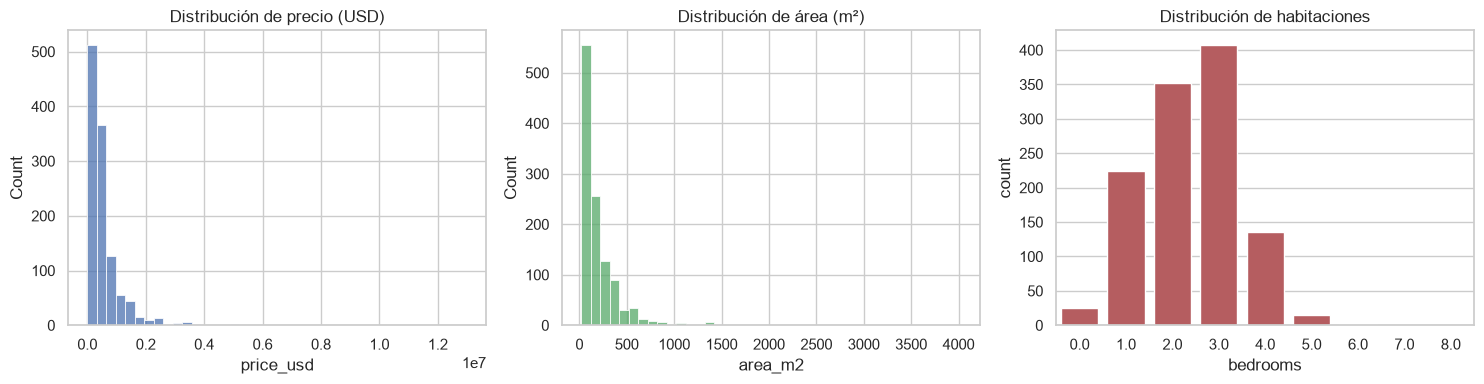

,price_usd,area_m2,bedrooms,bathrooms
count,1.163000e+03,1141.000000,1163.000000,1163.000000
mean,5.718518e+05,207.798422,2.402408,2.408426
std,6.970144e+05,246.810847,1.062453,1.112825
min,1.500000e+03,21.000000,0.000000,0.000000
25%,2.319550e+05,80.000000,2.000000,2.000000
50%,3.600000e+05,127.000000,2.000000,2.000000
75%,6.439750e+05,244.000000,3.000000,3.000000
max,1.300000e+07,4026.000000,8.000000,8.000000


In [16]:
df_graficable = df_limpio.loc[df_limpio["precio_no_evaluable"] == False]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_graficable["price_usd"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de precio (USD)")

sns.histplot(df_graficable["area_m2"], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Distribución de área (m²)")

sns.countplot(data=df_graficable, x="bedrooms", ax=axes[2], color="#C44E52",
              order=sorted(df_graficable["bedrooms"].dropna().unique()))
axes[2].set_title("Distribución de habitaciones")

plt.tight_layout()
plt.show()

df_graficable[["price_usd", "area_m2", "bedrooms", "bathrooms"]].describe()


### 4.4 Incorporación del enriquecimiento de `tipo_inmueble` y `descripcion`

`pipeline/scraper/enriquecer_detalle.py` (documentado en `Context-MD/Acta_1.2_Adenda_Duplicados.md`
§9) visita la página de detalle de cada listing por fuera de este notebook — es un proceso de
scraping de ~1,177 requests con cortesía de 2.5s entre cada una, no algo que quepa ejecutar dentro
de una celda. Incorporamos su resultado ya calculado, leyendo las columnas nuevas
(`tipo_inmueble`, `descripcion`, `descripcion_fuente`, `enriquecimiento_estado`) desde el propio
archivo de salida de este notebook, si ya existen ahí de una ejecución previa del enriquecimiento —
así, re-ejecutar este notebook no descarta un enriquecimiento ya calculado.


In [17]:
OUTPUT_PATH = PROCESSED_DIR / "catalogo_residencial_limpio_6_2_1.csv"
COLUMNAS_ENRIQUECIMIENTO = ["listing_id", "tipo_inmueble", "descripcion", "descripcion_fuente", "enriquecimiento_estado"]

if OUTPUT_PATH.exists():
    df_previo = pd.read_csv(OUTPUT_PATH)
    columnas_presentes = [c for c in COLUMNAS_ENRIQUECIMIENTO if c in df_previo.columns]
    if len(columnas_presentes) > 1:
        lookup_enriquecimiento = df_previo[columnas_presentes].drop_duplicates(subset="listing_id")
        df_limpio = df_limpio.merge(lookup_enriquecimiento, on="listing_id", how="left")
        print(f"Enriquecimiento incorporado desde ejecución previa: "
              f"{df_limpio['tipo_inmueble'].notna().sum()} / {len(df_limpio)} filas con tipo_inmueble")
    else:
        print("El archivo de salida existe pero no tiene columnas de enriquecimiento todavía.")
else:
    print("No existe ejecución previa de enriquecimiento -- df_limpio queda sin estas columnas por ahora.")


Enriquecimiento incorporado desde ejecución previa: 1177 / 1177 filas con tipo_inmueble


## 5. Redefinición de "comparable" — corregimiento + tipo_inmueble

In [18]:
columnas_comparable = ["corregimiento"] + (["tipo_inmueble"] if "tipo_inmueble" in df_limpio.columns else [])

comparables = (
    df_limpio.groupby(columnas_comparable)
    .size()
    .rename("n_comparables")
    .reset_index()
    .sort_values("n_comparables", ascending=False)
)
comparables.head(15)


,corregimiento,tipo_inmueble,n_comparables
18,San Francisco,Apartamentos,466
5,Costa del Este,Apartamentos,185
0,Bella Vista,Apartamentos,178
7,El Cangrejo,Apartamentos,72
12,Obarrio,Apartamentos,64
1,Betania,Apartamentos,62
11,Marbella,Apartamentos,49
19,zona_no_determinada,Apartamentos,48
13,Parque Lefevre,Apartamentos,14
2,Betania,Casas,14


Redefinimos "comparable" de proximidad geográfica (`ST_Distance`) — inválida porque `geom` de
propiedades es sintético y nunca insumo de modelo — a agrupación por **corregimiento + tipo de
inmueble**, tal como quedó diseñado originalmente en la decisión #4 del Acta de Feature 1.2. Ya no
es una definición degradada a solo corregimiento: con el enriquecimiento de la sección 4.4,
`tipo_inmueble` está poblado para 1,168 / 1,177 filas (`enriquecimiento_estado == "ok"`). En la
práctica, dado que el filtro de scraping ya deja el catálogo prácticamente homogéneo en tipo
("Apartamentos" en la enorme mayoría de los casos, verificado en `Context-MD/Acta_1.2_Adenda_Duplicados.md`
§9.2), agrupar por corregimiento + tipo_inmueble no fragmenta mucho más los grupos que agrupar solo
por corregimiento — pero la definición ya no depende de una columna ausente, y queda lista para
zonas o fuentes futuras donde el tipo sí varíe más. Pedregal y Parque Lefevre quedan con muy pocos
comparables tras la limpieza, consistente con su exclusión ya documentada de KNN/KMeans por volumen
insuficiente para validación estadística mínima. Los registros con `corregimiento ==
"zona_no_determinada"` (53) quedan fuera de cualquier grupo de comparables hasta que se resuelvan
manualmente — ningún notebook de entrenamiento posterior debe asignarlos a una zona por inferencia
propia.


## 6. Exportación del dataset limpio

In [19]:
df_limpio.to_csv(OUTPUT_PATH, index=False)
print(f"Exportado: {OUTPUT_PATH.resolve()}")
print(f"Filas: {len(df_limpio)}  |  Columnas: {list(df_limpio.columns)}")


Exportado: /Users/heliocastillo/Proyecto-REIP/Real-Estate-Intelligence-Platform/pipeline/data/processed/catalogo_residencial_limpio_6_2_1.csv
Filas: 1177  |  Columnas: ['listing_url', 'listing_id', 'title', 'zone_raw', 'corregimiento', 'zone_source', 'price_raw', 'price_usd', 'precio_no_evaluable', 'precio_no_evaluable_motivo', 'bedrooms', 'bathrooms', 'area_m2', 'operation', 'source', 'scraped_at', 'corregimiento_archivo', 'tipo_inmueble', 'descripcion', 'descripcion_fuente', 'enriquecimiento_estado']


## 7. Conclusiones

Consolidamos 1,361 registros scrapeados en un único catálogo y, al hacerlo por primera vez,
encontramos 184 duplicados cross-file entre Bella Vista y las tres zonas que heredan de ella
(El Cangrejo, Obarrio, Marbella) — un artefacto de la consolidación, no del scraping por zona
individual, que verificamos contra los conteos ya validados en el Acta de Feature 1.2. La cifra
operativa para los notebooks de entrenamiento posteriores queda en 1,177 registros
(`pipeline/data/processed/catalogo_residencial_limpio_6_2_1.csv`), manteniendo
`precio_no_evaluable` como columna flag en vez de descartar esas filas del dataset maestro.

Confirmamos, con la tabla del Acta de Feature 1.2, que Costa del Este, Marbella y San Francisco
concentran la mayor discrepancia entre volumen proyectado y real (-84%, -75%, -48%), y que el
filtro de tipo de inmueble aplicado durante el scraping deja el catálogo consolidado sin residuos
detectables de tipos no residenciales. Incorporamos el enriquecimiento de `tipo_inmueble` y
`descripcion` (ejecutado con `pipeline/scraper/enriquecer_detalle.py`, documentado en
`Context-MD/Acta_1.2_Adenda_Duplicados.md` §9), con 1,168 / 1,177 filas exitosas —
`tipo_inmueble` deja de ser una columna ausente, y la redefinición de "comparable" ya no está
degradada a solo corregimiento: usa corregimiento + tipo_inmueble tal como se diseñó originalmente.

Corregimos también, en este mismo notebook, la inconsistencia de formato que encontramos en la
columna `corregimiento`: normalizamos la variante de mayúsculas de Costa del Este (191 filas) contra
la clave canónica de Zone Health, y resolvimos, con dos niveles de confianza verificables dentro del
propio catálogo, 18 de los 71 registros de zona ambigua que el Acta de Feature 1.2 describe como ya
resueltos manualmente sin evidencia de que esa resolución se haya ejecutado. Los 53 casos restantes
quedan marcados como `zona_no_determinada`, sin asignación por inferencia, documentados con título y
URL en `Context-MD/Acta_1.2_Adenda_Duplicados.md` para revisión manual posterior. Agregamos los 3
mapeos de PH/edificio verificados por cross-referencia interna (Condesa del Mar, Rivage, Mirador del
Golf) a `PH_A_COREGIMIENTO` en el scraper, para que corridas futuras los resuelvan automáticamente.
